Using chemical analysis to determine the origin of wines


https://archive.ics.uci.edu/dataset/109/wine

These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. 



# Import

In [159]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt 
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


# Data Loading

In [160]:
# fetch dataset 
wine = fetch_ucirepo(id=109) 
  
# data (as pandas dataframes) 
X = wine.data.features 
y = wine.data.targets 
  
# metadata 
print(wine.metadata) 
  
# variable information 
print(wine.variables)

{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

# Data Insights

In [161]:
X.info()
print("---------------------------------------")
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Alcohol                       178 non-null    float64
 1   Malicacid                     178 non-null    float64
 2   Ash                           178 non-null    float64
 3   Alcalinity_of_ash             178 non-null    float64
 4   Magnesium                     178 non-null    int64  
 5   Total_phenols                 178 non-null    float64
 6   Flavanoids                    178 non-null    float64
 7   Nonflavanoid_phenols          178 non-null    float64
 8   Proanthocyanins               178 non-null    float64
 9   Color_intensity               178 non-null    float64
 10  Hue                           178 non-null    float64
 11  0D280_0D315_of_diluted_wines  178 non-null    float64
 12  Proline                       178 non-null    int64  
dtypes: float64(11), 

In [162]:
X.describe()

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


class
2        71
1        59
3        48
Name: count, dtype: int64
class
2        0.398876
1        0.331461
3        0.269663
Name: proportion, dtype: float64


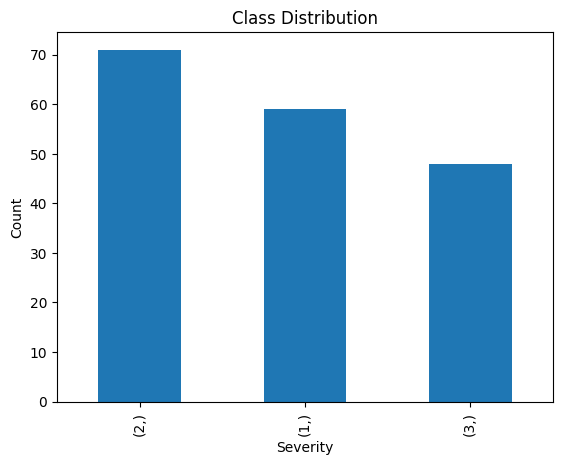

In [163]:
print(y.value_counts())
print(y.value_counts(normalize=True))

y.value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

--> no missing values

--> all numerical, no categorical data

--> imbalanced dataset

# Target Encoding

In [164]:
y

,class
0,1
1,1
2,1
3,1
4,1
...,...
173,3
174,3
175,3
176,3


In [165]:
le = LabelEncoder()
y = pd.Series(
    le.fit_transform(y['class']),
    index=y.index,
    name="class"
)
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: class, Length: 178, dtype: int64

# Train Test Split

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("y value counts normalized: \n", y.value_counts(normalize=True))
print("---------------------------------------")
print("y_train value counts normalized: \n", y_train.value_counts(normalize=True))
print("---------------------------------------")
print("---------------------------------------")
print("y_test value counts normalized: \n", y_test.value_counts(normalize=True))

y value counts normalized: 
 class
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64
---------------------------------------
y_train value counts normalized: 
 class
1    0.401408
0    0.330986
2    0.267606
Name: proportion, dtype: float64
---------------------------------------
---------------------------------------
y_test value counts normalized: 
 class
1    0.388889
0    0.333333
2    0.277778
Name: proportion, dtype: float64


# Outlier Handling

In [167]:
for col in X_train.select_dtypes(include="number").columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()

    print(f"{col}:")
    print(f"  Lower bound: {lower_bound}")
    print(f"  Upper bound: {upper_bound}")
    print(f"  Number of outliers: {n_outliers}\n")

Alcohol:
  Lower bound: 10.584999999999997
  Upper bound: 15.345000000000002
  Number of outliers: 0

Malicacid:
  Lower bound: -0.7299999999999998
  Upper bound: 5.51
  Number of outliers: 1

Ash:
  Lower bound: 1.6600000000000004
  Upper bound: 3.0999999999999996
  Number of outliers: 2

Alcalinity_of_ash:
  Lower bound: 10.749999999999998
  Upper bound: 27.950000000000003
  Number of outliers: 3

Magnesium:
  Lower bound: 58.375
  Upper bound: 137.375
  Number of outliers: 3

Total_phenols:
  Lower bound: 0.06250000000000044
  Upper bound: 4.442499999999999
  Number of outliers: 0

Flavanoids:
  Lower bound: -1.09375
  Upper bound: 5.0962499999999995
  Number of outliers: 0

Nonflavanoid_phenols:
  Lower bound: 0.030000000000000054
  Upper bound: 0.6699999999999999
  Number of outliers: 0

Proanthocyanins:
  Lower bound: 0.20000000000000018
  Upper bound: 3.0
  Number of outliers: 2

Color_intensity:
  Lower bound: -1.63
  Upper bound: 10.870000000000001
  Number of outliers: 2

Hue

In [168]:
for col in X_train.select_dtypes(include="number").columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)


In [169]:
for col in X_train.select_dtypes(include="number").columns:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    n_outliers = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()

    print(f"{col}:")
    print(f"  Lower bound: {lower_bound}")
    print(f"  Upper bound: {upper_bound}")
    print(f"  Number of outliers: {n_outliers}\n")

Alcohol:
  Lower bound: 10.584999999999997
  Upper bound: 15.345000000000002
  Number of outliers: 0

Malicacid:
  Lower bound: -0.7299999999999998
  Upper bound: 5.51
  Number of outliers: 0

Ash:
  Lower bound: 1.6600000000000004
  Upper bound: 3.0999999999999996
  Number of outliers: 0

Alcalinity_of_ash:
  Lower bound: 10.749999999999998
  Upper bound: 27.950000000000003
  Number of outliers: 0

Magnesium:
  Lower bound: 58.375
  Upper bound: 137.375
  Number of outliers: 0

Total_phenols:
  Lower bound: 0.06250000000000044
  Upper bound: 4.442499999999999
  Number of outliers: 0

Flavanoids:
  Lower bound: -1.09375
  Upper bound: 5.0962499999999995
  Number of outliers: 0

Nonflavanoid_phenols:
  Lower bound: 0.030000000000000054
  Upper bound: 0.6699999999999999
  Number of outliers: 0

Proanthocyanins:
  Lower bound: 0.20000000000000018
  Upper bound: 3.0
  Number of outliers: 0

Color_intensity:
  Lower bound: -1.63
  Upper bound: 10.870000000000001
  Number of outliers: 0

Hue

# Scaling

In [170]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled

,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
36,0.385801,-0.639617,1.836729,-1.238984,0.763065,0.526865,0.732292,-0.169549,-0.417960,-0.162731,0.638630,0.252908,0.467725
30,0.948519,-0.767915,1.294090,0.872185,0.118040,1.172795,1.333181,-0.590457,1.402711,0.323099,1.088034,0.151048,1.815768
26,0.523354,-0.520484,0.984011,-1.058027,-0.455316,0.930572,1.006382,-0.169549,-0.257313,-0.074399,-0.125359,0.893172,1.516203
12,0.973529,-0.557140,0.170052,-1.088186,-0.741993,0.526865,0.816627,-0.590457,0.385277,0.278933,0.908272,0.427526,1.932265
148,0.435820,0.826643,0.053773,0.570589,-0.526985,-0.555068,-1.291756,0.756449,-0.614307,1.524426,-1.788157,-1.435059,-0.297831
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,0.685917,0.762494,1.371610,1.173780,-0.168638,-1.168702,-1.544762,1.177357,-1.863787,-0.273148,-0.260180,-0.794796,-0.730536
87,-1.652489,-0.612125,0.984011,1.927769,-0.813663,-0.571216,-0.395693,0.335541,-0.453659,-1.046060,1.852023,0.878620,-0.590739
34,0.673412,-0.492991,1.100291,-0.183400,0.763065,0.123159,0.574163,-0.590457,-0.096665,-0.339397,0.683570,0.383871,1.183353
163,-0.014354,1.019089,-0.062507,-0.334198,0.476387,-1.427074,-1.355008,0.335541,-1.167648,0.137600,-1.203930,-1.245891,-0.214618


# Over- and Undersampling

In [171]:
smote = SMOTE(random_state=42)
rus = RandomUnderSampler(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

X_train_scaled_smote, y_train_scaled_smote = smote.fit_resample(X_train_scaled, y_train)
X_train_scaled_rus, y_train_scaled_rus = rus.fit_resample(X_train_scaled, y_train)


print('Unbalanced')
print(y_train.value_counts())
print('\n SMOTE')
print(y_train_smote.value_counts())
print('\n RandomUnderSampler')
print(y_train_rus.value_counts())

Unbalanced
class
1    57
0    47
2    38
Name: count, dtype: int64

 SMOTE
class
0    57
2    57
1    57
Name: count, dtype: int64

 RandomUnderSampler
class
0    38
1    38
2    38
Name: count, dtype: int64


In [172]:
datasets_unscaled = {
    "unbalanced": (X_train, y_train),
    "smote": (X_train_smote, y_train_smote),
    "rus": (X_train_rus, y_train_rus)
}

datasets_scaled = {
    "unbalanced": (X_train_scaled, y_train),
    "smote": (X_train_scaled_smote, y_train_scaled_smote),
    "rus": (X_train_scaled_rus, y_train_scaled_rus)
}

# Modelling

We use the models we learned in lecture.

## Logistic Regression

In [173]:
LogReg_models = {}
for name, (X_tr, y_tr) in datasets_scaled.items():
    model = LogisticRegression(
        penalty='l2',          # Regularisierungstyp: 'l1', 'l2', 'elasticnet' oder None
        C=1.0,                 # Stärke der Regularisierung (kleiner = stärkere Regularisierung)
        solver='lbfgs',        # Optimierungsalgorithmus: z.B. 'lbfgs', 'liblinear', 'saga'
        max_iter=500,          # Maximale Anzahl an Iterationen für die Optimierung
        tol=1e-4,              # Abbruchkriterium: Training stoppt bei kleiner Änderung
        random_state=42,       # Für reproduzierbare Ergebnisse
        fit_intercept=True,    # Ob ein Bias / Intercept gelernt werden soll
        class_weight=None,     # Kann z.B. 'balanced' sein bei unausgeglichenen Klassen
    )
    model.fit(X_tr, y_tr)
    LogReg_models[name] = model

LogReg_models

c:\Users\chris\Documents\GitHub\ML_DL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\chris\Documents\GitHub\ML_DL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\chris\Documents\GitHub\ML_DL\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

{'unbalanced': LogisticRegression(max_iter=500, penalty='l2', random_state=42),
 'smote': LogisticRegression(max_iter=500, penalty='l2', random_state=42),
 'rus': LogisticRegression(max_iter=500, penalty='l2', random_state=42)}

## k-NN

In [174]:
KNN_models = {}
for name, (X_tr, y_tr) in datasets_scaled.items():
    model = KNeighborsClassifier(
        n_neighbors=5,          # Anzahl der Nachbarn
        weights='uniform',      # 'uniform' = alle Nachbarn gleich wichtig
                                # 'distance' = nähere Nachbarn stärker gewichten
        algorithm='auto',       # Suchalgorithmus: 'auto', 'ball_tree', 'kd_tree', 'brute'
        leaf_size=30,           # Relevant für ball_tree und kd_tree
        p=2,                    # Distanzmaß: p=1 => Manhattan, p=2 => Euclidean
        metric='minkowski',     # Distanzmetrik: 'euclidean', 'manhattan', 'minkowski', etc.
    )
    model.fit(X_tr, y_tr)
    KNN_models[name] = model

KNN_models

{'unbalanced': KNeighborsClassifier(),
 'smote': KNeighborsClassifier(),
 'rus': KNeighborsClassifier()}

## SVM

In [175]:
SVM_models = {}
for name, (X_tr, y_tr) in datasets_scaled.items():
    model = SVC(
        C=1.0,                 # Regularisierungsparameter:
                               # kleiner -> stärkere Regularisierung
                               # größer -> Modell versucht Trainingsdaten stärker zu fitten
        
        kernel='rbf',          # Kernel-Typ:
                               # 'linear', 'poly', 'rbf', 'sigmoid'
        
        gamma='scale',         # Einfluss einzelner Trainingspunkte:
                               # 'scale' = Standard, oft gute Wahl
                               # 'auto' oder numerische Werte wie 0.01, 0.1
        
                 
        tol=1e-3,              # Abbruchkriterium
               
        class_weight=None,     # z.B. 'balanced' bei unausgeglichenen Klassen
        
        max_iter=-1,           # -1 = keine feste Iterationsgrenze
        
        decision_function_shape='ovr',  # Multi-Class-Strategie: 'ovr' oder 'ovo'
               
        random_state=42        # Für reproduzierbare Ergebnisse
    )
    model.fit(X_tr, y_tr)
    SVM_models[name] = model

SVM_models

{'unbalanced': SVC(random_state=42),
 'smote': SVC(random_state=42),
 'rus': SVC(random_state=42)}

## Random Forest

In [176]:
RF_models = {}
for name, (X_tr, y_tr) in datasets_unscaled.items():
    model = RandomForestClassifier(
        n_estimators=200,         # Anzahl der Bäume im Wald
        criterion='gini',         # Kriterium für die Aufteilung: 'gini' oder 'entropy'
        max_depth=None,           # Maximale Tiefe der Bäume; None = unbegrenzt
        min_samples_split=2,      # Minimale Anzahl Samples, um einen Knoten zu splitten
        min_samples_leaf=1,       # Minimale Anzahl Samples in einem Blattknoten
        max_features='sqrt',      # Anzahl Features pro Split: 'sqrt', 'log2' oder None
        max_leaf_nodes=None,      # Maximale Anzahl Blattknoten; None = unbegrenzt
        random_state=42,          # Für reproduzierbare Ergebnisse
        class_weight=None,        # z.B. 'balanced' bei unausgeglichenen Klassen
        max_samples=None          # Anzahl Samples pro Baum, falls bootstrap=True
    )
    
    model.fit(X_tr, y_tr)
    RF_models[name] = model

RF_models

{'unbalanced': RandomForestClassifier(n_estimators=200, random_state=42),
 'smote': RandomForestClassifier(n_estimators=200, random_state=42),
 'rus': RandomForestClassifier(n_estimators=200, random_state=42)}

## XGBoost

In [177]:
XGB_models = {}
for name, (X_tr, y_tr) in datasets_unscaled.items():
    model = XGBClassifier(
        n_estimators=200,         # Anzahl der Bäume
        max_depth=4,              # Tiefe der Bäume
        learning_rate=0.1,        # Lernrate
        subsample=0.8,            # Anteil der Daten pro Baum
        colsample_bytree=0.8,     # Anteil der Features pro Baum
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
    model.fit(X_tr, y_tr)
    XGB_models[name] = model

XGB_models

{'unbalanced': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3, ...),
 'smote': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             

# Testing

## Logistig Regression

In [178]:
LogReg_preds = {}
for name, model in LogReg_models.items():
    y_pred = model.predict(X_test_scaled)
    LogReg_preds[name] = y_pred

for name, y_pred in LogReg_preds.items():
    print(f"=== Logistic Regression - {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

=== Logistic Regression - unbalanced ===
Accuracy: 0.9722222222222222
Macro F1: 0.9709618874773139
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


=== Logistic Regression - smote ===
Accuracy: 0.9722222222222222
Macro F1: 0.9709618874773139
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.

## K-NN

In [179]:
KNN_preds = {}
for name, model in KNN_models.items():
    y_pred = model.predict(X_test_scaled)
    KNN_preds[name] = y_pred

for name, y_pred in KNN_preds.items():
    print(f"=== K-Nearest Neighbors - {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

=== K-Nearest Neighbors - unbalanced ===
Accuracy: 1.0
Macro F1: 1.0
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


=== K-Nearest Neighbors - smote ===
Accuracy: 0.9722222222222222
Macro F1: 0.974320987654321
Confusion Matrix:
 [[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg      

## SVM

In [180]:
SVM_preds = {}
for name, model in SVM_models.items():
    y_pred = model.predict(X_test_scaled)
    SVM_preds[name] = y_pred

for name, y_pred in SVM_preds.items():
    print(f"=== Support Vector Machine - {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

=== Support Vector Machine - unbalanced ===
Accuracy: 0.9722222222222222
Macro F1: 0.9709618874773139
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


=== Support Vector Machine - smote ===
Accuracy: 0.9722222222222222
Macro F1: 0.9709618874773139
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97  

## Random Forest

In [181]:
RF_preds = {}
for name, model in RF_models.items():
    y_pred = model.predict(X_test)
    RF_preds[name] = y_pred

for name, y_pred in RF_preds.items():
    print(f"=== Random Forest - {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

=== Random Forest - unbalanced ===
Accuracy: 1.0
Macro F1: 1.0
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


=== Random Forest - smote ===
Accuracy: 1.0
Macro F1: 1.0
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


===

## XGBoost

In [182]:
XGBoost_preds = {}
for name, model in XGB_models.items():
    y_pred = model.predict(X_test)
    XGBoost_preds[name] = y_pred

for name, y_pred in XGBoost_preds.items():
    print(f"=== XGBoost - {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

=== XGBoost - unbalanced ===
Accuracy: 1.0
Macro F1: 1.0
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


=== XGBoost - smote ===
Accuracy: 1.0
Macro F1: 1.0
Confusion Matrix:
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


=== XGBoost - r